## Quantum Walk

### Quantum Walk Circuit

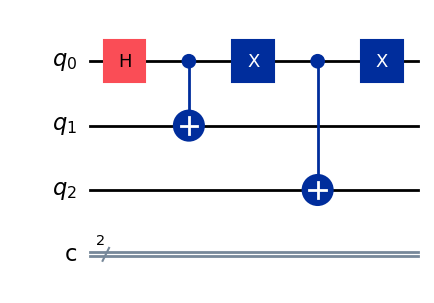

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np

# 1 coin qubit + 2 position qubits
qc = QuantumCircuit(3, 2)

coin = 0
pos = [1,2]

# Step 1: Initialize coin in superposition
qc.h(coin)

# Step 2: Shift operation (controlled movement)
# If coin = 0 → move left
qc.cx(coin, pos[0])

# If coin = 1 → move right
qc.x(coin)
qc.cx(coin, pos[1])
qc.x(coin)

qc.draw('mpl')

In [2]:
sv = Statevector.from_instruction(qc)
print(sv)

Statevector([0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j],
            dims=(2, 2, 2))


### Multi-Step Quantum Walk

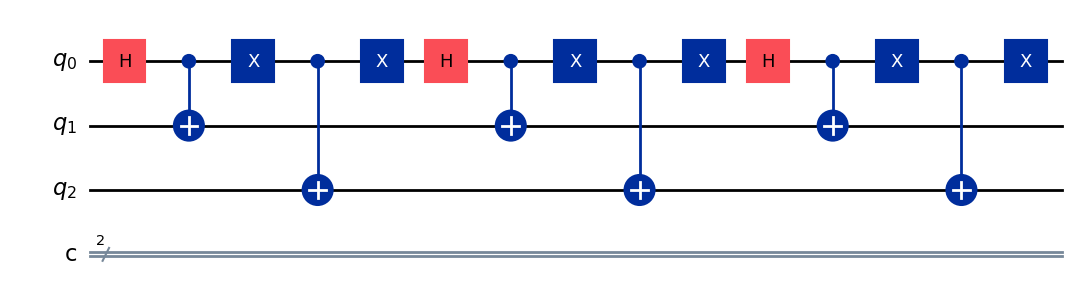

In [3]:
def quantum_walk(steps):
    qc = QuantumCircuit(3, 2)
    coin = 0
    pos = [1,2]

    for _ in range(steps):
        # Coin toss
        qc.h(coin)

        # Shift
        qc.cx(coin, pos[0])

        qc.x(coin)
        qc.cx(coin, pos[1])
        qc.x(coin)

    return qc

qc_walk = quantum_walk(3)
qc_walk.draw('mpl')

In [4]:
qc_walk.measure([1,2], [0,1])

sim = AerSimulator()
result = sim.run(qc_walk, shots=1024).result()
counts = result.get_counts()

print(counts)

{'01': 1024}
